In [15]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    RocCurveDisplay
)

import matplotlib.pyplot as plt
import numpy as np
import joblib
import pandas as pd

In [8]:
def log_transform(X):
	"""Custom log transformation function"""
	return np.log1p(X)

preprocessor = joblib.load("C:\\Users\\xws\\Desktop\\credit-risk-ml\\artifacts\\preprocessor.joblib")

print(preprocessor)

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('log',
                                                  FunctionTransformer(func=<function log_transform at 0x0000017B8C43E160>)),
                                                 ('scaler', StandardScaler())]),
                                 ['age', 'no_of_days_employed',
                                  'total_family_members', 'migrant_worker',
                                  'yearly_debt_payments', 'credit_limit',
                                  'credit_limit_used(%)', 'credit_score',
                                  'prev_defaults', 'default_in_last_6months']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_fre

In [14]:
train_path = 'C:\\Users\\xws\\Desktop\\credit-risk-ml\\data\\train (1).csv'
test_path = 'C:\\Users\\xws\\Desktop\\credit-risk-ml\\data\\test.csv'

# Chargement
train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

X = train_df.drop(columns=["customer_id", "name", "credit_card_default"])
y = train_df["credit_card_default"]

In [16]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Train:", X_train.shape)
print("Valid:", X_valid.shape)

print("Default ratio train:", y_train.mean())
print("Default ratio valid:", y_valid.mean())

Train: (36422, 16)
Valid: (9106, 16)
Default ratio train: 0.08121465048597001
Default ratio valid: 0.08115528223149572


In [17]:
from sklearn.pipeline import Pipeline

baseline_model = Pipeline([
    ("preprocessing", preprocessor),
    ("model", LogisticRegression(
        max_iter=3000,
        class_weight="balanced",
        random_state=42
    ))
])

In [18]:
baseline_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('log',
                                                                   FunctionTransformer(func=<function log_transform at 0x0000017B8C43E160>)),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'no_of_days_employed',
                                                   'total_family_members',
                                                   'migrant_worker',
                                                   'yearly_debt_payments',
                                                   'credit_limit',
                                                   'credit_limit_used(%)',
                                                   'credit_score',
                                                   'prev_defaults',
                                                   'default_in_last_6months']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['gender', 'owns_car',
                                                   'owns_house',
                                                   'occupation_type'])])),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=3000,
                                    random_state=42))])

In [19]:
y_pred = baseline_model.predict(X_valid)
y_proba = baseline_model.predict_proba(X_valid)[:,1]

In [20]:
print(classification_report(y_valid, y_pred))

print("F1 :", f1_score(y_valid, y_pred))
print("Precision :", precision_score(y_valid, y_pred))
print("Recall :", recall_score(y_valid, y_pred))
print("ROC AUC :", roc_auc_score(y_valid, y_proba))

              precision    recall  f1-score   support

           0       1.00      0.95      0.97      8367
           1       0.65      0.96      0.77       739

    accuracy                           0.95      9106
   macro avg       0.82      0.96      0.87      9106
weighted avg       0.97      0.95      0.96      9106

F1 : 0.7744401966138722
Precision : 0.6492673992673993
Recall : 0.959404600811908
ROC AUC : 0.9939424697159874


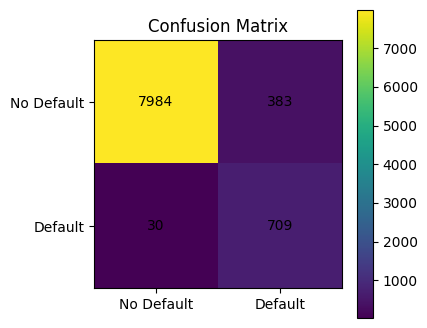

In [21]:
cm = confusion_matrix(y_valid, y_pred)

plt.figure(figsize=(4,4))
plt.imshow(cm)
plt.title("Confusion Matrix")

plt.xticks([0,1],["No Default","Default"])
plt.yticks([0,1],["No Default","Default"])

for i in range(2):
    for j in range(2):
        plt.text(j,i,cm[i,j],ha="center",va="center")

plt.colorbar()
plt.show()

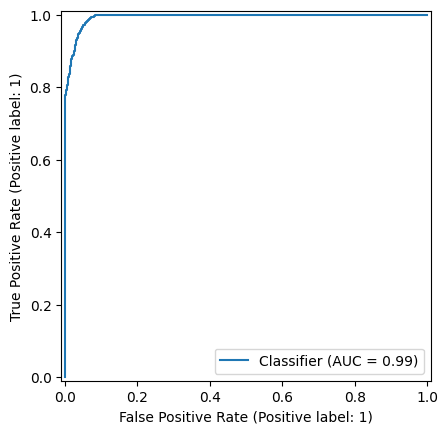

In [22]:
RocCurveDisplay.from_predictions(y_valid, y_proba)
plt.show()

In [23]:
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = cross_val_score(
    baseline_model,
    X,
    y,
    scoring="f1",
    cv=skf,
    n_jobs=-1
)

print("F1 scores:", cv_scores)
print("Mean F1:", cv_scores.mean())

F1 scores: [0.74830641 0.76303063 0.75630252 0.76334232 0.76568365]
Mean F1: 0.7593331046925761


In [24]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

smote_model = ImbPipeline([
    ("preprocessing", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("model", LogisticRegression(
        max_iter=3000,
        random_state=42
    ))
])

In [25]:
smote_model.fit(X_train, y_train)

y_pred_sm = smote_model.predict(X_valid)

print(classification_report(y_valid, y_pred_sm))
print("F1 SMOTE:", f1_score(y_valid, y_pred_sm))

c:\Users\xws\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


              precision    recall  f1-score   support

           0       1.00      0.96      0.98      8367
           1       0.66      0.96      0.78       739

    accuracy                           0.96      9106
   macro avg       0.83      0.96      0.88      9106
weighted avg       0.97      0.96      0.96      9106

F1 SMOTE: 0.7783902976846747


In [26]:
results = {
    "Baseline_F1": f1_score(y_valid, y_pred),
    "SMOTE_F1": f1_score(y_valid, y_pred_sm)
}

results

{'Baseline_F1': 0.7744401966138722, 'SMOTE_F1': 0.7783902976846747}

In [ ]:
import numpy as np
from sklearn.metrics import f1_score, precision_score, recall_score

thresholds = np.linspace(0.05, 0.95, 181)

best_t, best_f1 = None, -1
best_stats = None

for t in thresholds:
    pred_t = (y_proba >= t).astype(int)
    f1 = f1_score(y_valid, pred_t)
    if f1 > best_f1:
        best_f1 = f1
        best_t = t
        best_stats = (
            precision_score(y_valid, pred_t),
            recall_score(y_valid, pred_t)
        )

print("Best threshold:", round(best_t, 3))
print("Best F1:", round(best_f1, 4))
print("Precision/Recall at best t:", tuple(round(x, 4) for x in best_stats))

Best threshold: 0.95
Best F1: 0.8599
Precision/Recall at best t: (0.9508, 0.7848)


Average Precision (PR-AUC): 0.949


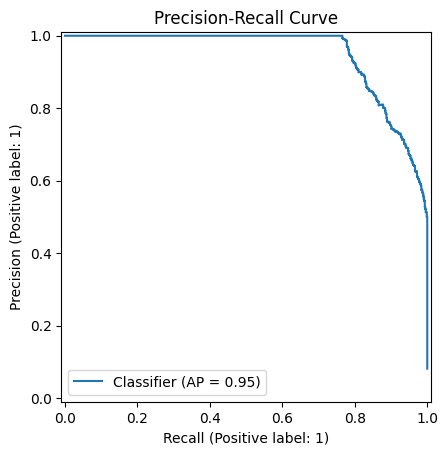

In [28]:
# CELLULE — Precision-Recall curve
from sklearn.metrics import PrecisionRecallDisplay, average_precision_score

ap = average_precision_score(y_valid, y_proba)
print("Average Precision (PR-AUC):", round(ap, 4))

PrecisionRecallDisplay.from_predictions(y_valid, y_proba)
plt.title("Precision-Recall Curve")
plt.show()

In [ ]:
import joblib
from pathlib import Path

ARTIFACTS = Path("artifacts")
ARTIFACTS.mkdir(exist_ok=True)

joblib.dump(baseline_model, ARTIFACTS/"credit_default_model.joblib")

joblib.dump(best_t, ARTIFACTS/"decision_threshold_lr.joblib")

print("✅ Model + threshold saved")

✅ Model + threshold saved
